# Probabilistic modeling of A/B compartments

This model infers A/B chromatin compartment structure from the first eigenvector (E1) of the Hi-C contact matrix using a Bayesian framework.

Here we implement dependency between bins with a Gaussian Random Walk (GRW) that is then squished through a sigmoid to obtain probabilities for compartment assignment. 

## Goals

To treat the eigenvector as a soft predictor in stead of deterministic assignment of compartments. Hopefully, we will salvage *some* variance and thus be able to obtain incertainty estimates for compartment assignment.

## Implementation: GRW on Latent Space

### Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from scipy.stats import norm
from pprint import pprint

## Use a custom style for the plots
plt.style.use('smaller.mplstyle')
%config InlineBackend.figure_formats = ['svg']


### Load/show data

Here, we load the Hi-C contact matrix and the first eigenvector (E1) of the contact matrix. The E1 is used as a predictor for compartment assignment.

The eigendecomposition of the Hi-C matrix was performed with the workflow in the main folder (`workflow.py`), using the **Open2C** ecosystem

In [19]:
# Load the data
# Low res example
resolution = 100000

y = pd.Series(pd.read_csv(f"../data/eigs/fibroblast.eigs.{resolution}.cis.vecs.tsv", sep="\t")['E1'].values.flatten())
x = pd.Series(np.arange(0,y.shape[0])*resolution)

# Make a DataFrame object
df = pd.DataFrame({"start": x, "e1": y})

~~The data are stored as pd.Series() objects, merged into a pd.DataFrame() that is not used. Maybe it would save some typing (for plots) to have the bin numbers converted into the genomic position, so that might be implemented in the future.~~ It already is...

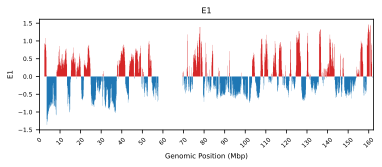

In [20]:
# Plot the data as a track (stairs for niceity)

fig, ax = plt.subplots()

x_stair = np.zeros(2*df.start.shape[0])
y_stair = np.zeros(2*y.shape[0])
x_stair[0::2] = df.start
x_stair[1::2] = df.start + resolution
y_stair[0::2] = df.e1
y_stair[1::2] = df.e1

ax.fill_between(x_stair, y_stair, where=(y_stair<0), color="tab:blue", ec='None')
ax.fill_between(x_stair, y_stair, where=(y_stair>0), color="tab:red", ec='None')

ax.set_xlim(0, df["start"].max()+resolution)
ticks = np.arange(0, df["start"].max()+resolution, step=1e7, dtype=int)
ax.set_xticks(ticks)
ax.set_xticklabels((ticks/1e6).astype(int), rotation=45)
ax.set_xlabel("Genomic Position (Mbp)")
ax.set_ylabel("E1")
ax.set_title("E1");

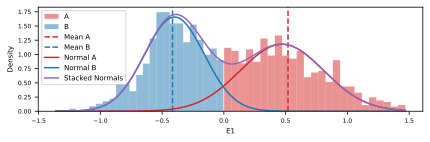

In [21]:
# Histogram of distribution of E1 values (A and B)

f, ax = plt.subplots()

# A compartments
ax.hist(y[y>0], bins=25, color="tab:red", alpha=0.5, label="A", density=True)
# B compartments
ax.hist(y[y<0], bins=25, color="tab:blue", alpha=0.5, label="B", density=True)
# Mean values (vline)
ax.axvline(y[y>0].mean(), color="tab:red", linestyle="--", label="Mean A")
ax.axvline(y[y<0].mean(), color="tab:blue", linestyle="--", label="Mean B")

# Plot the normal distributions
x_values = np.linspace(y.min(), y.max(), 1000)
mean_a = y[y>0].median()
mean_b = y[y<0].median()
std_a = y[y>0].std()
std_b = y[y<0].std()

ax.plot(x_values, norm.pdf(x_values, loc=mean_a, scale=std_a), color="tab:red", label="Normal A")
ax.plot(x_values, norm.pdf(x_values, loc=mean_b, scale=std_b), color="tab:blue", label="Normal B")
stacked = norm.pdf(x_values, loc=mean_a, scale=std_a) + norm.pdf(x_values, loc=mean_b, scale=std_b)
ax.plot(x_values, stacked, color="tab:purple", label="Stacked Normals")

# Final touches
plt.xlabel("E1")
plt.ylabel("Density")
plt.legend(loc='best')
plt.tight_layout()

### Model Specification

Here, the structure of the model is as follows:

We keep the assumption that the E1 values can be drawn from two Gaussian priors, one for A compartments and one for B compartments. To introduce spatial dependency, we use rolling regression with a Gaussian Random Walk (GRW) prior on the latent state variable (`p`) that is then squished through a sigmoid function.  

**NB** We only use a GRW on the latent variable in this model as a simpler alternative GRW on the E1. Guess what comes next.

**Notation** 

Let: 
- $y_i$: Observed E1 value at bin $i$
- $ z_i \in \{0, 1\} $: Latent compartment assignment (0 = B, 1 = A)
- $ \mu_A, \mu_B $: Mean E1 values for compartments A and B
- $ \sigma $: Shared standard deviation across bins
- $ p $: Prior probability of a bin belonging to compartment A

**Model Variables**

$$
\begin{aligned}
\mu_A &\sim \mathcal{N}(0.5, 0.5) \\
\mu_B &\sim \mathcal{N}(-0.5, 0.5) \\
\sigma &\sim \text{HalfNormal}(1) \\
logit(p) &\sim \text{GaussianRandomWalk}(\sigma) \\
p_i &\sim \text{Sigmoid}(logit(p)) \\
z_i &\sim \text{Bernoulli}(p_i) \\
\mu_i &= z_i \cdot \mu_A + (1 - z_i) \cdot \mu_B \\
y_i &\sim \mathcal{N}(\mu_i, \sigma) \\
\end{aligned}
$$

### PyMC

In [ ]:
with pm.Model() as model:
    # Means for compartments
    mu_a = pm.Normal("mu_a", 0.5, 0.2)
    mu_b = pm.Normal("mu_b", -0.5, 0.2)

    # Shared noise
    sigma = pm.HalfNormal("sigma", 0.3)

    # Spatial smoothing on latent logits
    logit_p = pm.GaussianRandomWalk("logit_p", sigma=1.0, shape=y.shape[0])

    # Get bin-wise probabilities via sigmoid
    p_i = pm.Deterministic("p_i", pm.math.sigmoid(logit_p))

    # Sample latent states with spatially smooth probabilities
    z = pm.Bernoulli("z", p=p_i)

    # Bin-specific mean
    mu = pm.math.switch(z, mu_a, mu_b)

    # Heavy-tailed likelihood
    nu = pm.HalfNormal("nu", 5)
    y_lik = pm.StudentT("y_lik", mu=mu, sigma=sigma, nu=nu, observed=y)

with model:
    trace = pm.sample(2000, tune=2000, chains=8, cores=8, target_accept=0.9)
